## 一、深度学习中神经网络的工作原理、梯度下降、损失函数与反向传播


**本节完整梳理**神经网络（Neural Network）的核心原理，从前向传播 → 损失函数 → 梯度下降 → 反向传播，一条龙讲解，并给出**PyTorch 现代实现**代码。

---

### 1. 神经网络基本结构与工作原理

神经网络由**输入层 → 隐藏层 → 输出层**堆叠而成，每层包含多个**神经元（Neuron）**。

单个神经元计算公式：

$$
z = \mathbf{w}^\top \mathbf{x} + b
$$

$$
a = \sigma(z) \quad (\sigma \text{为激活函数，如 ReLU、Sigmoid、Tanh})
$$

- **前向传播（Forward Propagation）**：从输入逐层计算直到输出。
- **核心思想**：通过大量参数（权重 + 偏置）自动学习特征，无需手工特征工程。

多层网络整体前向传播（以两层为例）：

$$
\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)
$$

$$
\hat{\mathbf{y}} = \sigma(\mathbf{W}_2 \mathbf{h} + \mathbf{b}_2)
$$

---

### 2. 常见损失函数（Loss Function）

#### 分类任务（最常用）
- **交叉熵损失（Cross Entropy）**（多分类）：

$$
L = -\sum_{i=1}^C y_i \log(\hat{y}_i)
$$

- **二分类交叉熵**：

$$
L = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]
$$

#### 回归任务
- **均方误差（MSE）**：

$$
L = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

- **MAE**（对异常值更鲁棒）：

$$
L = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
$$

---

### 3. 梯度下降算法（Gradient Descent）

**核心公式**（参数更新）：

$$
\theta \leftarrow \theta - \eta \cdot \nabla_\theta L
$$

- $\theta$：所有参数（w、b）
- $\eta$：学习率（learning rate）
- $\nabla_\theta L$：损失对参数的梯度

#### 常见变体
- **批量梯度下降（Batch GD）**：用全部样本计算梯度（慢但稳定）
- **随机梯度下降（SGD）**：每次用一个样本（快但震荡）
- **小批量梯度下降（Mini-batch GD）**：实际最常用（batch_size=32/64/128）
- **Momentum**（动量）：

$$
v_t = \beta v_{t-1} + (1-\beta) \nabla L
$$

$$
\theta \leftarrow \theta - \eta v_t
$$

- **Adam**（目前最流行）：

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t
$$

$$
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \text{（自适应缩放梯度）}
$$

$$
\theta \leftarrow \theta - \eta \frac{m_t}{\sqrt{v_t} + \epsilon}
$$
若初始化为0，即$m_0 = 0, v_0 = 0$, 则可以进行如下偏差修正，即：
$$
m_t = \frac{\beta_1 m_{t-1} + (1-\beta_1) g_t}{1-\beta_1^t}
$$

$$
v_t = \frac{\beta_2 v_{t-1} + (1-\beta_2) g_t^2}{1-\beta_2^t}
$$

$$
\theta \leftarrow \theta - \eta \frac{m_t}{\sqrt{v_t} + \epsilon}
$$
---

### 4. 反向传播（Backpropagation）—— 神经网络训练的核心

反向传播本质是**链式求导法则**（Chain Rule）的应用。

#### 核心公式推导（两层网络示例）

损失 $ L $ 对输出层权重 $\mathbf{W}_2$ 的梯度：

$$
\frac{\partial L}{\partial \mathbf{W}_2} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial \mathbf{W}_2}
$$

对隐藏层权重 $\mathbf{W}_1$ 的梯度（关键链式传递）：

$$
\frac{\partial L}{\partial \mathbf{W}_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial \mathbf{h}} \cdot \frac{\partial \mathbf{h}}{\partial z_1} \cdot \frac{\partial z_1}{\partial \mathbf{W}_1}
$$

**面试必背口诀**：
“前向算输出 → 计算损失 → 反向逐层求梯度（从输出层到输入层）→ 用梯度更新参数”

---

### 5.常见激活函数及作用
#### 一、核心作用（3点必答）
1. **引入非线性**
   线性层仅做$wx+b$，多层叠加仍等价于单层；激活函数提供非线性，让网络可拟合任意复杂函数（通用逼近定理）。
2. **控制信号流动**
   筛选有效特征，决定神经元是否激活，实现信息筛选。
3. **稳定训练**
   缓解梯度消失/爆炸，加速收敛，提升模型泛化能力。

---

#### 二、核心激活函数（公式+特点+适用场景）
##### 1. Sigmoid
$$
\sigma(x) = \frac{1}{1+e^{-x}}
$$
- 输出：$(0,1)$，可表示概率
- 缺点：**梯度消失严重**、非零均值、计算量大
- 适用：**二分类输出层**，隐藏层几乎不用

##### 2. Tanh
$$
\tanh(x) = \frac{e^x-e^{-x}}{e^x+e^{-x}}
$$
- 输出：$(-1,1)$，零均值
- 缺点：**饱和区（输入的绝对值很大时）梯度消失**
- 适用：早期RNN，现已少用

##### 3. ReLU（默认首选）
$$
f(x) = \max(0, x)
$$
- 优点：计算极快、正区间无梯度消失、稀疏性好
- 缺点：**Dying ReLU**（负输入梯度为0，神经元失活）
- 适用：**CNN/DNN隐藏层**

##### 4. Leaky ReLU
$$
f(x) = \max(\alpha x, x), \alpha=0.01
$$
- 优点：解决Dying ReLU，负输入保留小梯度
- 适用：ReLU失效时替代

##### 5. GELU（Transformer标配）
$$
f(x) = x \cdot \Phi(x)
$$
- 优点：平滑、无边界、训练稳定
- 适用：Transformer、大模型

---

#### 三、面试高频结论
1. **隐藏层默认用ReLU**，简单高效；
2. **Transformer/GPT/ViT用GELU**；
3. Sigmoid/Tanh仅用于特殊输出层，隐藏层禁用；
4. 激活函数的**核心价值是非线性**，无激活则网络无表达能力。

#### 四、一句话总结
激活函数为网络引入**非线性**，决定表达能力；ReLU/GELU是工业界主流，Sigmoid/Tanh因梯度消失仅用于特定场景。

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. 定义网络（不变）
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

# 2. 数据准备（XOR 问题）
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

# 包装成 Dataset 和 DataLoader（关键部分）
dataset = TensorDataset(X, y)

# batch_size 可以设为 1～4，这里演示 batch_size=2
train_loader = DataLoader(
    dataset,
    batch_size=2,          # 小批量大小（可调：1=纯SGD，全部=全批量）
    shuffle=True,          # 每个 epoch 随机打乱（非常重要）
    drop_last=False        # 数据量小，不丢弃最后不足 batch 的部分
)

# 3. 模型、损失、优化器
model = Net()
criterion = nn.BCELoss()                # 二分类交叉熵
optimizer = optim.SGD(model.parameters(), lr=0.1)   # 也可以换成 SGD
# optimizer = optim.SGD(model.parameters(), lr=0.5, momentum=0.9)  # 纯 SGD 示例

# 4. 训练循环（Mini-batch 版）
epochs = 5000
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        # 前向
        outputs = model(batch_X)
        
        # 计算损失
        loss = criterion(outputs, batch_y)
        
        # 反向传播
        loss.backward()
        
        # 参数更新
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    # 每 1000 个 epoch 打印一次平均 loss
    if (epoch + 1) % 1000 == 0:
        avg_loss = epoch_loss / num_batches
        print(f"Epoch {epoch+1:4d}, Avg Loss: {avg_loss:.6f}")

# 5. 最终预测
model.eval()
with torch.no_grad():
    predictions = model(X)
    print("\n最终预测结果（概率）：")
    print(predictions.numpy().round(4).flatten())
    print("真实标签：", y.numpy().flatten())

Epoch 1000, Avg Loss: 0.689948
Epoch 2000, Avg Loss: 0.508589
Epoch 3000, Avg Loss: 0.064699
Epoch 4000, Avg Loss: 0.028332
Epoch 5000, Avg Loss: 0.017736

最终预测结果（概率）：
[0.0168 0.9828 0.98   0.0163]
真实标签： [0. 1. 1. 0.]


## 二、CNN（卷积神经网络）

**CNN 是深度学习在图像、视频、语音等领域最核心的网络结构**。  
它的核心思想是 **“局部连接 + 权重共享 + 平移不变性”**，通过卷积核自动提取图像特征，大幅减少参数量。

---

### 1. CNN 基本结构

典型 CNN 流程：  
**输入图像 → 卷积层（Conv）→ 激活（ReLU）→ 池化（Pooling）→ … → 全连接层（FC）→ 输出**

---

### 2. 核心公式（必须掌握）

#### 2.1 卷积操作（Convolution）—— CNN 的灵魂

二维卷积公式（单通道）：

$$
(I * K)(i,j) = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} I(i+m, j+n) \cdot K(m,n)
$$

- $I$：输入特征图（Image）
- $K$：卷积核（Kernel/Filter），通常 3×3、5×5
- 带**步长（Stride）**和**填充（Padding）**后的输出尺寸：

$$
H_{out} = \left\lfloor \frac{H_{in} + 2P - K_h}{S} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor \frac{W_{in} + 2P - K_w}{S} \right\rfloor + 1
$$

多通道卷积（实际最常用）：

$$
O_c = \sum_{d=1}^{D} I_d * K_{c,d}
$$

（每个输出通道是对所有输入通道卷积结果求和）

#### 2.2 池化层（Pooling）

- **Max Pooling**（最常用）：

$$
O(i,j) = \max_{m,n} I(i \cdot S + m, j \cdot S + n)
$$

- **Average Pooling**：

$$
O(i,j) = \frac{1}{k \times k} \sum I
$$

#### 2.3 激活函数（Activation）

最常用 **ReLU**：

$$
ReLU(x) = \max(0, x)
$$

#### 2.4 全连接层（Fully Connected）

与普通神经网络相同：

$$
\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}
$$

---

### 2.2池化层详解
#### 一、核心作用
1. **下采样（降维）**
   缩小特征图宽高，减少计算量与参数量，防止过拟合。
2. **增大感受野**
   相当于让后续卷积核“看到”更大的图像区域，提取更宏观特征。
3. **提供平移不变性**
   目标微小位移不影响输出，提升鲁棒性。
4. **特征聚合**
   保留关键信息，过滤冗余噪声，做轻量正则化。


#### 二、常见池化（公式+特点）
##### 1. Max Pooling（最大池化，默认首选）
$$
y = \max(\text{window})
$$
- 优点：保留最强特征，鲁棒，效果最好
- 缺点：丢失部分细节
- 适用：CNN 隐藏层标配

##### 2. Average Pooling（平均池化）
$$
y = \frac{1}{K^2}\sum(\text{window})
$$
- 优点：平滑特征，保留全局信息
- 缺点：弱化强特征，对噪声敏感
- 适用：早期CNN、末尾特征融合

##### 3. Global Average Pooling(GAP)
$$
y = \frac{1}{H\times W}\sum_{i,j} x_{i,j}
$$
- 优点：无参数，降维到通道维度，防过拟合
- 适用：现代CNN（ResNet）输出层替代全连接

---

#### 三、输出尺寸公式
$$
H_{out} = \left\lfloor\frac{H_{in} + 2P - K}{S}\right\rfloor + 1
$$
$$
W_{out} = \left\lfloor\frac{W_{in} + 2P - K}{S}\right\rfloor + 1
$$
- 最常用：$K=2, S=2, P=0$ → **尺寸直接减半**

---

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ==================== 1. 定义 CNN 模型 ====================
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        # 卷积块1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 卷积块2
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # 全连接层
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)          # 10 类输出
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x shape: (batch, 1, 28, 28)
        x = self.relu(self.conv1(x))          # → (batch, 6, 28, 28)
        x = self.pool1(x)                     # → (batch, 6, 14, 14)
        
        x = self.relu(self.conv2(x))          # → (batch, 16, 10, 10)
        x = self.pool2(x)                     # → (batch, 16, 5, 5)
        
        x = x.view(x.size(0), -1)             # Flatten
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)                       # 输出 logits
        return x

# ==================== 2. 数据加载 ====================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# ==================== 3. 模型、损失、优化器 ====================
model = LeNet5()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==================== 4. 训练循环 ====================
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

# ==================== 5. 测试准确率 ====================
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"测试集准确率: {100 * correct / total:.2f}%")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.36MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 158kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.43MB/s]


Epoch [1/10], Loss: 0.2159
Epoch [2/10], Loss: 0.0617
Epoch [3/10], Loss: 0.0445
Epoch [4/10], Loss: 0.0336
Epoch [5/10], Loss: 0.0285
Epoch [6/10], Loss: 0.0238
Epoch [7/10], Loss: 0.0201
Epoch [8/10], Loss: 0.0166
Epoch [9/10], Loss: 0.0148
Epoch [10/10], Loss: 0.0136
测试集准确率: 98.82%


## 三、Normalization 的作用

### 1. 数据预处理阶段的 Normalization（Feature Scaling）

#### 常见方法
- **Min-Max Normalization**  
  $$
  x' = \frac{x - \min}{\max - \min} \quad \rightarrow [0,1] 或 [-1,1]
  $$

- **Z-score Standardization**（最常用）  
  $$
  x' = \frac{x - \mu}{\sigma} \quad \rightarrow \text{均值0，方差1}
  $$

#### 核心作用（为什么一定要做？）
1. 消除不同特征之间的**量纲/尺度差异**  
   （面积几百㎡ vs 卧室数 1~5，尺度差几百倍）

2. **加速梯度下降收敛**（最重要收益之一）  
   - 损失函数等高线从很扁的椭圆 → 接近圆形  
   - 梯度方向更稳定 → 可以用更大的学习率  
   - 收敛速度通常提升 **几倍到十几倍**

3. 让**距离敏感型算法**正常工作  
   KNN、SVM、K-Means、神经网络等都严重依赖特征尺度

4. 提高**数值稳定性**，防止梯度爆炸/消失

5. 让**正则化项**（L1/L2）对所有特征更公平

**树模型（XGBoost、LightGBM、RandomForest）基本不需要**

### 2. 神经网络训练中的 Normalization 层（最核心部分）

#### （1）Batch Normalization（BN）——2015年里程碑

**完整计算流程（一个 mini-batch）**
1. 计算 batch 均值与方差  
   $$
   \mu_B = \frac{1}{m}\sum x_i \qquad \sigma_B^2 = \frac{1}{m}\sum (x_i - \mu_B)^2
   $$

2. 归一化  
   $$
   \hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
   $$

3. 尺度 + 偏移（可学习）  
   $$
   y_i = \gamma \cdot \hat{x}_i + \beta
   $$

#### （2）BN 带来的最关键效果（排序按重要程度）
1. **缓解 Internal Covariate Shift**（内部协变量偏移）  
   前几层参数更新 → 后面层输入分布剧烈变化 → BN 强制每层输入接近 N(0,1)

2. **允许使用更大的学习率**（实际提升最大）  
   学习率可提高 **10–30倍**，训练速度显著加快

3. **具有轻微正则化效果**（类似轻量 Dropout）  
   batch 统计的噪声 → 降低过拟合

4. **对权重初始化变得不敏感**  
   即使初始化很差也能较快恢复

5. **梯度更稳定**，深层网络更容易训练



#### （3）在与Adam自适应缩放梯度的对比中看BN的优点
##### 1. Adam 做的是：自适应缩放梯度
Adam 本质是：
$$
\Delta\theta = -\mathrm{lr}\cdot\frac{\hat{g}}{\sqrt{\hat{v}}+\epsilon}
$$
- 梯度 $g$ 大 → $\sqrt{\hat{v}}$ 也大 → **步长被自动缩小**
- 梯度 $g$ 小 → 步长相对变大

所以 Adam **确实能抑制梯度爆炸**。



##### 2. 但 BN 解决的是另一回事：**分布漂移 + 尺度不稳定**
没有 BN 时，即使是 Adam，也会遇到两个问题：

1. 每层输入的尺度一直在“整体漂移”

> 比如某一层输入从 `~1` 慢慢变成 `~10` 再变成 `~100`
→ 权重的有效尺度也跟着变
→ **Adam 的历史梯度估计（m、v）不断失效**
→ 自适应机制**跟不上分布的漂移**
→ 你依然**不敢用大 lr**，怕某一层突然尺度跳变导致震荡。



2. 特征分布不在激活函数“最舒服区”

> 即使 Adam 把步长压稳了，
如果输入落在 Sigmoid / Tanh 饱和区，或者 ReLU 大量死区，
**梯度依然会整体偏小、质量差**，
Adam 只是让你“稳一点地慢”，
**不能让你学得更快。**



##### 3. BN + Adam 才是王炸
**BN 做了 Adam 做不到的事：**

1. **固定每层输入的尺度和分布**（均值 0，方差 1）
2. **让激活永远落在敏感区**
3. **让每层的梯度量级稳定**

结果：
- 梯度**质量高**
- 分布**不漂移**
- Adam 的动量与自适应**能稳定工作**

→ 你可以**把 lr 设得更大**，依然不炸、不震荡。



##### 4.总结
> Adam 只能对梯度做**自适应缩放**，解决梯度爆炸问题；
> 但 BN 能**稳定每层特征的分布与尺度**，避免内部协变量偏移，
> 让梯度的**量级和分布都稳定**，使 Adam 的自适应机制更有效，
> 因此可以使用**更大、更激进的学习率**，加速收敛。



#### （4）BN 的主要缺点（催生了后续变体）
- 强依赖 batch size（太小统计不准，太大吃显存）
- 时序模型（RNN/Transformer）难以处理变长序列
- 测试阶段需要 running mean/variance

### 3. 主流 Normalization 家族对比（2025年视角）

| 类型          | 沿哪个维度算均值/方差       | 依赖 batch size? | 最适合的场景                        | 代表模型 / 架构              |
|---------------|-----------------------------|------------------|-------------------------------------|-------------------------------|
| BatchNorm     | N×C×H×W 中的 N（batch）     | 是               | 传统 CNN，大 batch                  | ResNet、DenseNet、Inception   |
| LayerNorm     | N×(C×H×W) 或序列最后一个维度 | 否               | Transformer、RNN、NLP、大模型       | BERT、GPT、LLaMA、ViT         |
| GroupNorm     | 通道分组                    | 否               | 小 batch、显存紧张的视觉任务        | ResNet（小 batch）、Mask R-CNN|
| InstanceNorm  | 每个样本每个通道单独        | 否               | 风格迁移、图像生成、GAN             | CycleGAN、AdaIN、StyleGAN     |
| RMSNorm       | 只算 RMS，不减均值          | 否               | 超大语言模型（更稳定、更快）        | LLaMA 系列、Grok、Gemma       |

### 4. 一句话总结 Normalization 的本质作用

**它把“每一层都在被迫适应前面层不断漂移的输入分布”这个问题，变成了“统一把输入拉到比较稳定的分布 + 让网络自己学 γ 和 β 来微调”**。

这直接解决了深度学习训练中最痛苦的两个问题：
- 训练极慢、收敛困难
- 梯度不稳定、深层网络难优化

几乎所有现代主流架构（ResNet → Transformer → Diffusion → LLM）都离不开某种形式的 Normalization。没有它，当前的大模型时代几乎不可能到来。

## 四、ResNet

### 一、核心思想（面试必背）
1. **解决深度网络的退化问题**
   网络层数加深 → 训练误差上升、精度下降（不是过拟合，是优化不动）。
2. **核心结构：残差块（Residual Block）**
   不学习完整的复杂特征映射，而是通过**跳跃连接（Shortcut）**让网络只学习**特征的增量**。
3. **关键性质**
   残差发生在**特征层面**，与标签/预测误差无关；
   让网络轻松实现**恒等映射**，大幅降低深层优化难度。

---

### 二、核心公式（手写必考）
#### 1. 残差块定义
$$
H(x) = x + F(x)
$$
- $x$：输入特征（跳跃连接，无参数变换）
- $F(x)$：卷积层学习的**特征增量**
- $H(x)$：残差块输出特征

#### 2. 残差数学表达
$$
F(x) = H(x) - x
$$
- 恒等式，由结构决定，**非监督学习目标**
- $F(x)$ 自动等于**输出特征与输入特征的差值**

---

### 三、核心作用（3 条）
1. **解决深度网络退化**
   想让输出等于输入（恒等映射），只需 $F(x)\to0$，极易优化。
2. **缓解梯度消失**
   梯度反向传播有**直达浅层的通道**，梯度乘积不易趋近于0。即：对于叫底层的参数而言，损失函数求梯度除原有非残差连接的梯度外还要一部分 $\frac{\partial X}{\partial w}$，这部分很大程度上缓解了梯度消失。
3. **支持训练极深网络**
   可训练 50/101/152 层深度网络，精度持续提升。

---

### 四、为什么是特征层面的残差？（面试必问）
- $x$ 和 $F(x)$ 都是**网络中间层的特征图**
- 运算发生在**特征空间**，全程不涉及标签 $y$
- 区别于 GBDT：GBDT 拟合**标签-预测**的误差残差

---

### 五、流程实例
<div style="display: flex; justify-content: center; align-items: center; gap: 20px;">
  <img src="./images/resnet_block1.png" style="width: 20%;" alt="ResNet模块结构图">
  <img src="./images/resnet_architecture.png" style="width: 20%;" alt="ResNet架构图">
</div>

In [2]:
import torch
import torch.nn as nn

# 标准残差块（通道相同）
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # 卷积路径：学习 F(x)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 跳跃连接 Shortcut
        self.shortcut = nn.Sequential()
        # 通道/尺寸不匹配时，1x1卷积调整
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        F = self.relu(self.bn1(self.conv1(x)))
        F = self.bn2(self.conv2(F))
        # 残差相加：x + F(x)
        out = F + self.shortcut(x)
        out = self.relu(out)
        return out

## 五、RNN（循环神经网络）

循环神经网络（RNN）是一类专门用于处理序列数据的神经网络。它通过引入“循环”连接，使得网络能够保留历史信息，从而对序列中的时间依赖关系进行建模。下面我将从思想、结构、前向传播、反向传播（BPTT）、常见变体、数学证明以及代码实现七个方面详细讲解。

---

### 1. 核心思想

RNN的核心在于**参数共享**和**循环连接**。对于序列数据 $ x_1, x_2, \dots, x_T $，传统全连接网络无法利用时间上的顺序信息，而RNN在每一时间步都使用相同的权重矩阵，并通过隐藏状态 $ h_t $ 将过去的信息传递到当前步：

$$
h_t = f(W_{xh} x_t + W_{hh} h_{t-1} + b_h)
$$

这里 $ h_t $ 不仅依赖于当前输入 $ x_t $，还依赖于上一时刻的隐藏状态 $ h_{t-1} $。这种结构使得RNN能够“记忆”历史信息，理论上可以建模任意长度的依赖关系。

---

### 2. 结构与流程

#### 2.1 基本单元

一个简单的RNN单元包含三个权重矩阵：
- $ W_{xh} $：输入到隐藏的权重
- $ W_{hh} $：隐藏到隐藏的权重（循环部分）
- $ W_{hy} $：隐藏到输出的权重

偏置项 $ b_h, b_y $ 可选。

#### 2.2 时间展开

将RNN按时间步展开，得到一个深层的网络，但每一层的权重是共享的。展开后的结构如下：

```
t=0:   x0 → [RNN单元] → h0 → y0
t=1:   x1 → [RNN单元] → h1 → y1
...          ↑
            h0
```

实际计算时，通常设置初始隐藏状态 $ h_0 $ 为零向量或可学习的参数。

#### 2.3 前向传播

给定输入序列 $ X = (x_1, x_2, \dots, x_T) $，每个 $ x_t \in \mathbb{R}^{d_x} $，隐藏状态 $ h_t \in \mathbb{R}^{d_h} $，输出 $ y_t \in \mathbb{R}^{d_y} $，前向传播公式为：

$$
\begin{aligned}
h_t &= \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h) \quad (1) \\
y_t &= W_{hy} h_t + b_y \quad (2)
\end{aligned}
$$

激活函数常用 $\tanh$ 或 $\text{ReLU}$。如果是分类任务，$ y_t $ 后常接 softmax 输出概率。

---

### 3. 反向传播（BPTT）

RNN的训练使用**随时间反向传播**（Backpropagation Through Time, BPTT）。其核心是将展开的网络视为一个深层前馈网络，然后计算每个时间步的梯度并累加。

#### 3.1 损失函数

假设任务为序列预测，定义损失 $ L = \sum_{t=1}^T L_t(y_t, \hat{y}_t) $。

#### 3.2 梯度计算

我们关注参数 $ W_{hh} $、$ W_{xh} $ 和 $ W_{hy} $ 的梯度。以 $ W_{hh} $ 为例，其梯度依赖于所有时间步的贡献：

$$
\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^T \frac{\partial L_t}{\partial W_{hh}}
$$

对于每个时间步 $ t $，根据链式法则：

$$
\frac{\partial L_t}{\partial W_{hh}} = \frac{\partial L_t}{\partial h_t} \cdot \frac{\partial h_t}{\partial W_{hh}}
$$

而 $ h_t $ 依赖于 $ h_{t-1} $，$ h_{t-1} $ 又依赖于更早的状态，因此需要递归地展开：

$$
\frac{\partial L_t}{\partial W_{hh}} = \frac{\partial L_t}{\partial h_t} \cdot \sum_{k=1}^t \left( \prod_{i=k+1}^t \frac{\partial h_i}{\partial h_{i-1}} \right) \cdot \frac{\partial h_k}{\partial W_{hh}} \Big|_{\text{direct}}
$$

其中 $ \frac{\partial h_t}{\partial h_k} = \prod_{i=k+1}^t \frac{\partial h_i}{\partial h_{i-1}} $。

对于 $\tanh$ 激活函数，有 $ \frac{\partial h_i}{\partial h_{i-1}} = \text{diag}(1 - h_i^2) W_{hh} $。因此，当 $ t-k $ 较大时，这个乘积会指数级地增长或衰减，导致**梯度爆炸**或**梯度消失**问题。

---

### 4. 梯度消失与爆炸的数学分析

假设激活函数为 $\tanh$，且忽略非线性项的尺度影响，近似地有 $ \frac{\partial h_t}{\partial h_{t-1}} \approx W_{hh} $。那么：

$$
\frac{\partial h_t}{\partial h_k} \approx (W_{hh})^{t-k}
$$

若 $ W_{hh} $ 的最大特征值 $ \lambda_{\max} > 1 $，则梯度随距离指数增长（爆炸）；若 $ \lambda_{\max} < 1 $，则梯度指数衰减（消失）。这导致RNN难以捕捉长距离依赖。

#### 4.1 缓解方法
- **梯度裁剪**：直接限制梯度的范数，防止爆炸。
- **改进结构**：LSTM 和 GRU 通过门控机制有效缓解消失问题。
- **初始化**：使用正交初始化保持特征值模长为1。
- **残差连接**：直接跨时间步连接。

---

### 5. RNN的常见变体

#### 5.1 LSTM（长短时记忆网络）

引入三个门（输入门、遗忘门、输出门）和一个细胞状态 $ c_t $，使得信息可以选择性地遗忘或保留，从而更好地捕捉长期依赖。

公式（简化）：
$$
\begin{aligned}
f_t &= \sigma(W_f [h_{t-1}, x_t] + b_f) \\
i_t &= \sigma(W_i [h_{t-1}, x_t] + b_i) \\
\tilde{c}_t &= \tanh(W_c [h_{t-1}, x_t] + b_c) \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
o_t &= \sigma(W_o [h_{t-1}, x_t] + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

#### 5.2 GRU（门控循环单元）

简化版LSTM，将遗忘门和输入门合并为更新门，同时合并细胞状态和隐藏状态。

公式：
$$
\begin{aligned}
z_t &= \sigma(W_z [h_{t-1}, x_t]) \\
r_t &= \sigma(W_r [h_{t-1}, x_t]) \\
\tilde{h}_t &= \tanh(W [r_t \odot h_{t-1}, x_t]) \\
h_t &= (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
\end{aligned}
$$

---



In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 数据准备：假设使用一小段文本
text = "hello world! this is a simple rnn example."
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)

# 超参数
hidden_size = 128
seq_length = 40  # 每个训练序列的长度
learning_rate = 0.01
num_epochs = 100

# 定义RNN模型
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, hidden_size)  # 可选的嵌入层
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, x, h0=None):
        # x shape: (batch, seq_len)
        x = self.embedding(x)  # (batch, seq_len, hidden_size)
        out, hn = self.rnn(x, h0)  # out: (batch, seq_len, hidden_size)
        out = self.fc(out)  # (batch, seq_len, vocab_size)
        return out, hn
    
    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_size)

# 准备数据：将文本转换为索引序列，并生成批次
def get_batch(data, seq_length, batch_size):
    # 简单的滑动窗口批次，实际训练中可随机采样
    num_batches = (len(data) - 1) // (seq_length * batch_size)
    inputs, targets = [], []
    for i in range(num_batches):
        start = i * seq_length * batch_size
        end = start + seq_length * batch_size
        batch_data = data[start:end+1]  # 多取一个作为目标
        batch_input = np.array(batch_data[:-1]).reshape(batch_size, seq_length)
        batch_target = np.array(batch_data[1:]).reshape(batch_size, seq_length)
        inputs.append(torch.tensor(batch_input, dtype=torch.long))
        targets.append(torch.tensor(batch_target, dtype=torch.long))
    return inputs, targets

# 将文本转为索引列表
data = [char_to_idx[ch] for ch in text]
inputs, targets = get_batch(data, seq_length, batch_size=1)

# 初始化模型、损失函数和优化器
model = CharRNN(vocab_size, hidden_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 训练循环
for epoch in range(num_epochs):
    total_loss = 0
    hidden = model.init_hidden(1)  # batch_size=2
    for inp, targ in zip(inputs, targets):
        hidden = hidden.detach()  # 防止梯度回传过远（可选）
        optimizer.zero_grad()
        output, hidden = model(inp, hidden)
        loss = criterion(output.view(-1, vocab_size), targ.view(-1))
        loss.backward()
        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        #把模型所有参数的梯度计算一个总范数（norm），如果这个总范数 超过了你设定的 max_norm（这里是 5），就按比例缩小所有梯度，让总范数等于 max_norm。
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(inputs):.4f}')

# 测试生成文本
def generate(model, start_char, length):
    model.eval()
    input_idx = torch.tensor([[char_to_idx[start_char]]], dtype=torch.long)
    hidden = model.init_hidden(1)
    generated = start_char
    for _ in range(length):
        output, hidden = model(input_idx, hidden)
        prob = torch.softmax(output[0, -1], dim=0).detach().numpy()
        next_idx = np.random.choice(vocab_size, p=prob)  # 按概率采样
        next_char = idx_to_char[next_idx]
        generated += next_char
        input_idx = torch.tensor([[next_idx]], dtype=torch.long)
    return generated

print(generate(model, start_char='h', length=50))

Epoch 10, Loss: 0.0350
Epoch 20, Loss: 0.0017
Epoch 30, Loss: 0.0005
Epoch 40, Loss: 0.0003
Epoch 50, Loss: 0.0002
Epoch 60, Loss: 0.0002
Epoch 70, Loss: 0.0002
Epoch 80, Loss: 0.0002
Epoch 90, Loss: 0.0002
Epoch 100, Loss: 0.0001
hello world! this is a simple rnn example rnn examp


### 代码详解总结
#### 一、模型整体流程（从头到尾顺序）
1. **文本 → 分词/分字符 → 数字索引**
2. **数字索引 → Embedding 层 → 向量**
3. **向量 → RNN 层 → 时序隐藏状态**
4. **隐藏状态 → 全连接层 FC → 输出概率**
5. **概率 → 损失函数 → 计算误差**
6. **反向传播 → 更新所有层参数（Embedding、RNN、FC）**



#### 二、每一层的作用 + 训练目标 + 损失函数（按顺序总结）

##### 1. 输入层：字符/词 → 数字索引
**作用**：把文本变成神经网络能处理的数字。
**规则**：每个字符/词对应唯一编号。



##### 2. Embedding 层（核心）
###### 它在干什么？
- 把**离散的数字索引** → **连续低维向量**
- 让模型能理解**字符/词之间的关系**（是否经常一起出现、是否语义相近）

###### 它的学习目标是什么？
**让输出的向量，能帮助后面的 RNN 更好地预测下一个字符/词。**

###### 它是怎么训练的？
- 由最终损失函数回传梯度
- 梯度一路传到 Embedding 权重矩阵
- 与 RNN、FC **一起更新**



##### 3. RNN 层（核心）
###### 它在干什么？
- 处理**序列数据**
- 维护**记忆（隐藏状态 hidden state）**
- 把前面的信息传递到后面，建模**上下文依赖**

###### 它的学习目标？
**根据前面的字符/词序列，输出能准确预测下一个字符/词的隐藏状态。**



##### 4. 全连接层 FC
###### 它在干什么？
- 把 RNN 输出的隐藏向量 → 映射到**词汇表大小的维度**
- 输出未归一化的分数（logits）


##### 5. 训练目标（整个模型的目标）
**给定前面的 N 个字符/词，预测下一个字符/词。**

这是 **语言模型（Language Model）** 的标准目标。



##### 6. 损失函数（CrossEntropyLoss）
###### 形式：
$$
Loss = -\frac{1}{T} \sum_{t=1}^T \log p(y_t | x_1,...,x_t)
$$



#### 三、总结
##### 1. Embedding 层
把数字转成**可学习向量**，让模型理解字符/词关系，**随模型一起训练**。

##### 2. RNN 层
利用**记忆**建模序列依赖，把前文信息传递到后文。

##### 3. 模型训练目标
**根据前文，预测下一个字符/词。**

##### 4. 损失函数
**最小化正确字符/词的负对数概率**，让预测越来越准。

##### 5. 整体学习逻辑
所有层（Embedding、RNN、FC）**共同朝着“预测下一个词”这个目标更新参数**。



## 六、Dropout

### 1. 引言

在深度学习中，模型参数众多，极易在训练集上过拟合，导致泛化能力下降。**Dropout** 是一种简单而有效的正则化技术，由 Hinton 等人在 2012 年提出。它通过在训练过程中随机丢弃一部分神经元，迫使网络学习更加鲁棒的特征，从而显著提升模型的泛化性能。

本文将深入探讨 Dropout 的思想、作用、理论证明、应用场景，并给出在循环神经网络（RNN）中的具体实现示例。

---

### 2. Dropout 的基本思想

Dropout 的核心思想：**在训练过程中，以一定的概率 $p$ 随机将神经元的输出置为 0（即“丢弃”该神经元）**。每次前向传播时，网络结构都会发生变化，相当于从原始网络中采样出一个子网络。测试时，不再丢弃神经元，而是使用完整的网络，并将每个神经元的输出乘以保留概率 $p$（或等价地，在训练时对输出进行缩放，使得测试时无需额外处理）。

#### 数学描述

设某一层的输入为 $\mathbf{x}$，经过线性变换后得到 $\mathbf{a} = \mathbf{W} \mathbf{x} + \mathbf{b}$，激活函数为 $f$。在训练阶段，我们生成一个与 $\mathbf{a}$ 同维度的掩码向量 $\mathbf{m}$，其每个元素独立地以概率 $p$ 为 1（保留），以概率 $1-p$ 为 0（丢弃）。则该层的输出为：

$$
\mathbf{h} = f\left(\mathbf{m} \odot \mathbf{a}\right)
$$

其中 $\odot$ 表示逐元素相乘。为了保持期望值不变，通常会在训练时对保留的神经元进行缩放：$\mathbf{h} = f\left(\frac{1}{p} \mathbf{m} \odot \mathbf{a}\right)$，这样在测试时只需直接使用完整网络即可。

---

### 3. Dropout 的作用

- **防止过拟合**：通过随机丢弃神经元，减少神经元之间的共适应关系，使网络不过度依赖某些特定特征。
- **提高泛化能力**：相当于对网络结构进行噪声注入，迫使模型学习更鲁棒的特征表示。
- **模型集成**：每次训练的子网络可以看作一个弱分类器，最终预测是这些子网络的平均，类似于 Bagging 的效果。
- **减少神经元之间的复杂协同**：防止某些神经元“协同工作”来拟合噪声，从而让每个神经元都能独立地学习有用的特征。

---

### 4. Dropout 的理论证明

#### 4.1 从模型平均的角度

假设原始网络有 $n$ 个神经元，则可能的子网络数量为 $2^n$（每个神经元都有丢弃/保留两种状态）。在训练过程中，每次只更新一个子网络的参数（参数共享），最终模型的输出可以看作是所有子网络输出的几何平均或算术平均（每个batch之间dropout掩码不同）。这种集成效果能有效降低泛化误差。

#### 4.2 从正则化的角度

有文献指出，Dropout 可以近似为对权重施加 $L_2$ 正则化。考虑一个简单的线性回归模型，加入 Dropout 后，损失函数的期望可以分解为原始损失加上一个关于权重的惩罚项。具体地，对于某一层的权重矩阵 $\mathbf{W}$，Dropout 引入的噪声导致损失函数中增加了 $\|\mathbf{W}\|_2^2$ 项（在特定假设下）。这解释了 Dropout 的正则化效果。

#### 4.3 从信息瓶颈角度

Dropout 强迫网络在存在随机干扰（随机丢弃）的情况下仍能正确预测，这相当于对网络的信息容量进行了约束，使网络学习到输入数据中最本质的信息，从而提升泛化。

---

### 5. Dropout 的应用场景

- **全连接网络（FCN）**：直接应用，通常在激活函数之前或之后添加 Dropout 层。
- **卷积神经网络（CNN）**：通常在卷积层之后、全连接层之前使用 Dropout。也可在卷积层中使用，但效果不如在全连接层中明显。近年来，更多采用 Batch Normalization 和 Dropout 结合的方式。
- **循环神经网络（RNN）**：直接对循环连接使用 Dropout 会随时间累积噪声，导致模型训练不稳定。因此常采用以下变体：
  - **变分 Dropout**：在时间步上共享相同的掩码，即整个序列使用同一个丢弃模式。
  - **仅在非循环连接上使用 Dropout**：例如，在 LSTM 的输入和输出层使用 Dropout，而对隐状态间的循环连接不使用。
  - **Recurrent Dropout**：对 LSTM 的隐状态或门控单元应用 Dropout，通常只在时间步之间共享掩码（即变分 Dropout）。

在 Keras 的 `LSTM` 层中，参数 `dropout` 控制输入和循环连接（如果 `recurrent_dropout` 未指定）上的丢弃率，而 `recurrent_dropout` 专门用于循环连接上的丢弃。

---

### 6. RNN 中的 Dropout 实现

#### 6.1 基本实现方式

在 RNN 中，为了保持时间一致性，通常采用 **变分 Dropout**：即在每个时间步上使用相同的掩码，这样不同时间步的丢弃模式一致，避免了噪声随时间累积。另一种常见做法是只在输入到隐层、隐层到输出的连接上使用 Dropout，而隐层到隐层的循环连接不使用。

#### 6.2 Keras 中的 LSTM Dropout

Keras 的 LSTM 层提供了两个参数：
- `dropout`：对输入和循环连接（如果 `recurrent_dropout=0`）施加的丢弃率。
- `recurrent_dropout`：仅对循环连接（隐状态之间的连接）施加的丢弃率，且使用变分 Dropout（时间步共享掩码）。

使用时通常将两者结合，如 `dropout=0.2, recurrent_dropout=0.2`。

#### 6.3 PyTorch 中的实现

PyTorch 中，`nn.LSTM` 也有 `dropout` 参数，它应用于非循环连接（即各层之间的连接），而循环连接上的 Dropout 需通过手动在循环层之间插入 `nn.Dropout` 实现，或者使用 `nn.RNN` 的 `dropout` 参数（仅多层时有效）。对于变分 Dropout，需要自定义实现。

---


### 7. 总结

Dropout 是一种简单而强大的正则化技术，通过随机丢弃神经元有效防止过拟合。它在全连接网络、CNN、RNN 中都得到了广泛应用。对于 RNN，需要特别注意 Dropout 的实现方式以避免时间步上的噪声累积，通常采用变分 Dropout 或仅对非循环连接使用。通过合理设置 Dropout 参数，可以显著提升模型的泛化能力。

在实际应用中，Dropout 常与 Batch Normalization、早停等技术结合使用，以达到最佳效果。

### 8.变分Dropout
**变分 Dropout（Variational Dropout）** 是专门针对循环神经网络（RNN）设计的一种 Dropout 变体，核心思想是：**在时间步上共享同一个丢弃掩码**，即在整个序列的前向传播过程中，丢弃的神经元位置保持不变。

---

#### 1. 为什么需要变分 Dropout？

在标准 Dropout 中，每个训练步骤（或每个 mini-batch）都会随机生成新的掩码。如果在 RNN 中直接对循环连接（隐状态到隐状态）使用这种独立采样的 Dropout，会出现两个问题：

- **噪声随时间累积**：每个时间步的掩码独立，导致隐状态在不同时间步受到的干扰不断叠加，使网络难以学习长期依赖。
- **破坏循环结构**：循环连接本身具有记忆性，独立掩码会破坏隐状态的时间一致性，使梯度传播不稳定。

变分 Dropout 通过在**所有时间步上固定掩码**，避免了上述问题。

---

#### 2. 变分 Dropout 的具体形式

假设 RNN 的输入为 $x_t$，隐状态为 $h_t$，循环权重为 $W_h$，输入权重为 $W_x$。在变分 Dropout 中：

- 对于输入连接（$W_x x_t$），生成一个掩码 $m_x$，在每个时间步都使用同一个 $m_x$ 进行丢弃。
- 对于循环连接（$W_h h_{t-1}$），生成一个掩码 $m_h$，同样在所有时间步共享。

数学表示（以 LSTM 为例）：

$$
\begin{aligned}
i_t &= \sigma\left( W_{xi} (x_t \odot m_x) + W_{hi} (h_{t-1} \odot m_h) + b_i \right) \\
f_t &= \sigma\left( W_{xf} (x_t \odot m_x) + W_{hf} (h_{t-1} \odot m_h) + b_f \right) \\
o_t &= \sigma\left( W_{xo} (x_t \odot m_x) + W_{ho} (h_{t-1} \odot m_h) + b_o \right) \\
\tilde{c}_t &= \tanh\left( W_{xc} (x_t \odot m_x) + W_{hc} (h_{t-1} \odot m_h) + b_c \right) \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

其中 $m_x$ 和 $m_h$ 是伯努利掩码，在整个序列的所有时间步中保持不变。

---

#### 3. 变分 Dropout 的实现

- **Keras / TensorFlow**：LSTM 层的 `recurrent_dropout` 参数默认实现了变分 Dropout（在循环连接上应用共享掩码）。
- **PyTorch**：原生 `nn.LSTM` 没有直接提供变分 Dropout，但可以通过手动在循环中固定掩码来实现。一些第三方库（如 `torchdropout`）提供了支持。

---

#### 4. 理论依据

变分 Dropout 由 Gal 和 Ghahramani 在 2016 年的论文《A Theoretically Grounded Application of Dropout in Recurrent Neural Networks》中系统提出。他们证明了：

- 在 RNN 上使用标准 Dropout 会导致网络无法近似模型平均，而变分 Dropout 则可以在时间上一致地近似贝叶斯模型平均。
- 变分 Dropout 等价于对 RNN 的权重施加一种变分推断，从而起到正则化作用。

---

#### 5. 与标准 Dropout 的对比

| 特性 | 标准 Dropout | 变分 Dropout |
|------|-------------|--------------|
| 掩码采样 | 每个时间步独立采样 | 所有时间步共享相同掩码 |
| 应用场景 | 全连接、CNN | RNN（特别是循环连接） |
| 对循环连接的影响 | 噪声随时间累积，不稳定 | 保持时间一致性，稳定 |
| 在 Keras LSTM 中的对应参数 | `dropout`（对输入和循环连接） | `recurrent_dropout`（仅对循环连接） |

---

#### 6. 实践建议

在构建 RNN 模型时，通常建议：
- 对非循环连接（如输入层、多层 RNN 之间的连接）使用标准 Dropout（`dropout` 参数）。
- 对循环连接使用变分 Dropout（`recurrent_dropout` 参数），并设置较小的丢弃率（如 0.2～0.3），以在正则化和记忆保持之间取得平衡。

---


## 七、LSTM

### 1. 引言：RNN 的困境与 LSTM 的诞生

循环神经网络（RNN）能够处理序列数据，但由于梯度消失/爆炸问题，难以学习长期依赖。标准 RNN 在反向传播时，梯度随时间步的乘积会指数级衰减或增长，导致模型无法记住遥远过去的信息。

**长短期记忆网络（LSTM）** 由 Hochreiter & Schmidhuber 于 1997 年提出，通过引入 **门控机制** 和 **细胞状态**，允许信息在时间步上选择性地保留或遗忘，从而有效解决了长期依赖问题。LSTM 已成为处理序列任务（如文本、语音、时间序列）的经典模型。

---

### 2. LSTM 的核心思想

LSTM 的核心是一个 **细胞状态（cell state）** $c_t$，它像一条传送带，贯穿整个序列，只进行少量线性交互，使信息容易保持不变。通过三个门控单元来控制信息的流动：

- **遗忘门（forget gate）**：决定哪些旧信息应该被丢弃。
- **输入门（input gate）**：决定哪些新信息应该被存储到细胞状态中。
- **输出门（output gate）**：决定当前细胞状态的哪些部分应该输出到隐藏状态。

这些门都是 sigmoid 层（输出 0~1），通过逐元素乘法控制信息流量。

---

### 3. 数学公式

记：
- $x_t$：当前时间步的输入向量
- $h_{t-1}$：上一时间步的隐藏状态
- $c_{t-1}$：上一时间步的细胞状态

**遗忘门**：
$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$
决定保留多少旧细胞状态。

**输入门**：
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$
$$
\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)
$$
$i_t$ 决定更新哪些位置，$\tilde{c}_t$ 是候选细胞状态。

**细胞状态更新**：
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$
旧的乘以遗忘门，新的乘以输入门，相加得到新细胞状态。

**输出门**：
$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$
$$
h_t = o_t \odot \tanh(c_t)
$$
输出门决定哪些细胞状态信息作为当前隐藏状态输出。

其中 $\odot$ 表示逐元素乘法，$\sigma$ 为 sigmoid 函数，$\tanh$ 为双曲正切函数。


---

### 4. 为什么 LSTM 能缓解梯度消失？

#### 4.1 传统 RNN 的梯度问题

在标准 RNN 中，反向传播时梯度包含连乘项 $\prod_{k=1}^{t} W_{hh}^T \cdot \text{diag}(\sigma'(h_k))$，容易导致梯度指数级消失或爆炸。

#### 4.2 LSTM 的梯度流动

LSTM 的细胞状态更新为：
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$
反向传播时，从 $c_t$ 到 $c_{t-1}$ 的梯度为：
$$
\frac{\partial c_t}{\partial c_{t-1}} = \text{diag}(f_t) + \text{（其他项，来自 } i_t, \tilde{c}_t \text{ 对 } c_{t-1} \text{ 的导数）}
$$
关键是 **遗忘门 $f_t$ 直接控制梯度传递**。当 $f_t$ 接近 1 时，梯度能几乎无衰减地通过细胞状态流回早期时间步；当 $f_t$ 接近 0 时，梯度会阻断，这正是模型学习要遗忘的信息。因此 LSTM 能够根据数据自适应地调整梯度传递，避免了固定的指数衰减。

#### 4.3 直观证明

考虑极端情况：设遗忘门 $f_t = 1$，输入门 $i_t = 0$，则细胞状态恒为常数：$c_t = c_{t-1}$。此时梯度可以完美地从 $t$ 时刻传到 0 时刻，没有衰减。实际训练中，LSTM 可以学习让遗忘门接近 1 以保留长期信息，或接近 0 以丢弃无关信息。这种门控机制使得梯度可以在必要时保持稳定，从而缓解消失问题。

---

### 5. 应用场景

LSTM 广泛应用于：

- **自然语言处理**：语言模型、机器翻译、文本分类、情感分析
- **时间序列预测**：股票价格、电力负荷、气象预测
- **语音识别**：声学建模、语音合成
- **视频分析**：动作识别、视频字幕生成
- **音乐生成**：旋律、和弦预测

---


### 6. 总结

LSTM 通过精巧的门控机制和细胞状态，实现了对长期依赖的有效建模。它的核心在于：

- **遗忘门**决定丢弃哪些旧信息
- **输入门**决定添加哪些新信息
- **输出门**决定隐藏状态的输出

这种设计使得梯度可以在细胞状态上稳定流动，缓解了传统 RNN 的梯度消失问题。在实际应用中，LSTM 及其变体（如 GRU）已成为序列建模的标配。

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

In [18]:
# 参数
seq_len = 10          # 输入序列长度
batch_size = 32
hidden_size = 64
num_layers = 2
learning_rate = 0.001
epochs = 100

# 生成正弦波
t = np.linspace(0, 100, 1000)
data = np.sin(t) + 0.1 * np.random.randn(len(t))   # 添加噪声

# 归一化
data = (data - data.min()) / (data.max() - data.min())

# 构造数据集
def create_sequences(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        x = data[i:i+seq_len]
        y = data[i+seq_len]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(data, seq_len)
X = X.reshape(-1, seq_len, 1)   # (样本数, 序列长度, 特征数)
y = y.reshape(-1, 1)

# 划分训练集和测试集
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 转换为Tensor并创建DataLoader
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMPredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))   # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :]               # 取最后一个时间步的输出（最后一步做损失）
        out = self.fc(out)
        return out

model = LSTMPredictor(input_size=1, hidden_size=hidden_size, num_layers=num_layers, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [20]:
train_losses = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

Epoch 20, Loss: 0.0031
Epoch 40, Loss: 0.0026
Epoch 60, Loss: 0.0025
Epoch 80, Loss: 0.0025
Epoch 100, Loss: 0.0025


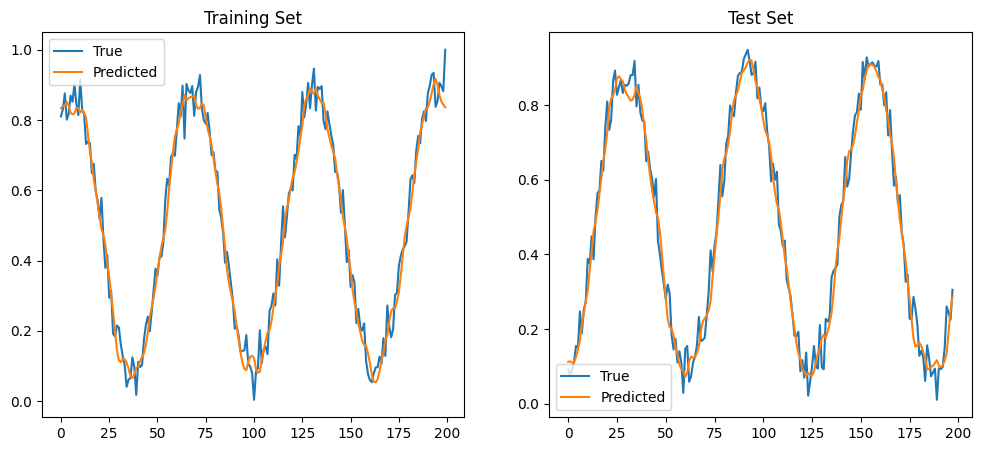

In [21]:
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t).numpy()
    y_pred_test = model(X_test_t).numpy()

# 绘制真实值与预测值
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(y_train[:200], label='True')
plt.plot(y_pred_train[:200], label='Predicted')
plt.title('Training Set')
plt.legend()

plt.subplot(1,2,2)
plt.plot(y_test[:200], label='True')
plt.plot(y_pred_test[:200], label='Predicted')
plt.title('Test Set')
plt.legend()
plt.show()